In [1]:
%matplotlib inline
import nest_asyncio
nest_asyncio.apply()

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'monospace'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['figure.facecolor'] = '#fafafa'
mpl.rcParams['axes.facecolor'] = '#fafafa'

In [2]:
import numpy as np
import pandas as pd

np.random.seed(2021)

n_weeks = 156
dates = pd.date_range(start='2021-01-04', periods=n_weeks, freq='W-MON')

# --- IBEX 35 price series (random walk, range 8200-9800) ---
price_start = 9000
steps = np.random.normal(0, 50, n_weeks)
prices_raw = price_start + np.cumsum(steps)
# rescale to [8200, 9800]
prices_min = prices_raw.min()
prices_max = prices_raw.max()
ibex_prices = 8200 + (prices_raw - prices_min) / (prices_max - prices_min) * 1600

# --- Weekly returns ---
ibex_returns = np.diff(ibex_prices) / ibex_prices[:-1]
ibex_returns = np.append(ibex_returns, np.nan)

# --- Sentiment scores (-1 to 1) ---
# lag-1 correlation injected by construction: sentiment at t encodes next week's return direction
noise = np.random.normal(0, 0.3, n_weeks)
signal = np.roll(ibex_returns, 1)  # sentiment[t] correlates with return[t+1]
signal[0] = 0
signal[-1] = 0
sentiment_raw = 0.6 * signal / (np.nanstd(signal) + 1e-9) + noise
# clip to [-1, 1]
sentiment = np.clip(sentiment_raw, -1, 1)

df = pd.DataFrame({
    'date': dates,
    'ibex_price': ibex_prices,
    'ibex_return': ibex_returns,
    'sentiment': sentiment
})

print('Shape:', df.shape)
print(df.head())

Shape: (156, 4)
        date   ibex_price  ibex_return  sentiment
0 2021-01-04  8347.322869     0.004286  -0.451015
1 2021-01-11  8383.099811    -0.002642   0.937986
2 2021-01-18  8360.953850    -0.005105   0.043417
3 2021-01-25  8318.269850     0.003537  -0.896587
4 2021-02-01  8347.688810    -0.004473  -0.072383


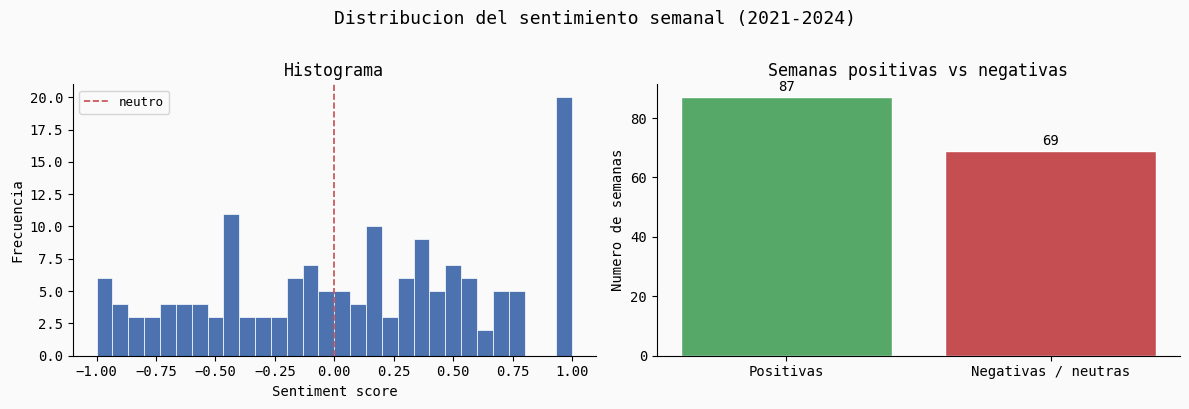

In [3]:
# --- Sentiment distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribucion del sentimiento semanal (2021-2024)', fontsize=13, y=1.01)

# Histogram
ax1 = axes[0]
ax1.hist(df['sentiment'], bins=30, color='#4c72b0', edgecolor='white', linewidth=0.5)
ax1.axvline(0, color='#c44e52', linestyle='--', linewidth=1.2, label='neutro')
ax1.set_xlabel('Sentiment score')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Histograma')
ax1.legend(fontsize=9)

# Positive vs negative weeks
ax2 = axes[1]
n_pos = (df['sentiment'] > 0).sum()
n_neg = (df['sentiment'] <= 0).sum()
bars = ax2.bar(['Positivas', 'Negativas / neutras'], [n_pos, n_neg],
               color=['#55a868', '#c44e52'], edgecolor='white')
for bar, val in zip(bars, [n_pos, n_neg]):
    label_str = str(val)
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             label_str, ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Numero de semanas')
ax2.set_title('Semanas positivas vs negativas')

plt.tight_layout()
plt.show()

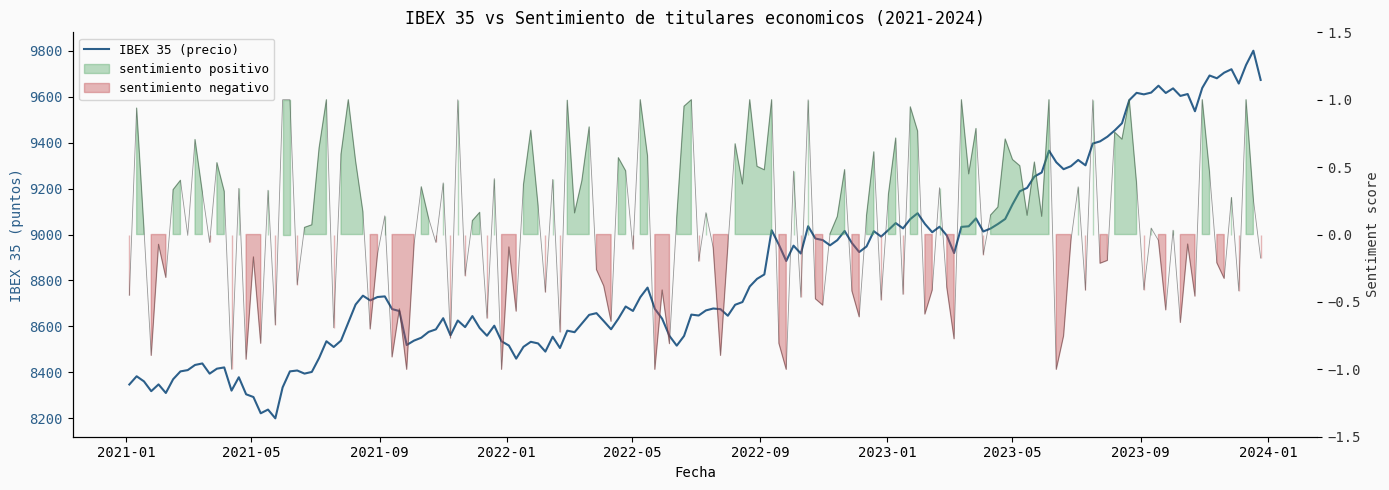

In [4]:
# --- Dual-axis time series: IBEX price vs sentiment ---
fig, ax1 = plt.subplots(figsize=(14, 5))

color_ibex = '#2c5f8a'
color_sent = '#c44e52'

ax1.plot(df['date'], df['ibex_price'], color=color_ibex, linewidth=1.5, label='IBEX 35 (precio)')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('IBEX 35 (puntos)', color=color_ibex)
ax1.tick_params(axis='y', labelcolor=color_ibex)
ax1.set_title('IBEX 35 vs Sentimiento de titulares economicos (2021-2024)', fontsize=12)

ax2 = ax1.twinx()
ax2.fill_between(df['date'], df['sentiment'], 0,
                 where=(df['sentiment'] >= 0), alpha=0.4, color='#55a868', label='sentimiento positivo')
ax2.fill_between(df['date'], df['sentiment'], 0,
                 where=(df['sentiment'] < 0), alpha=0.4, color=color_sent, label='sentimiento negativo')
ax2.plot(df['date'], df['sentiment'], color='#333333', linewidth=0.6, alpha=0.5)
ax2.set_ylabel('Sentiment score', color='#333333')
ax2.tick_params(axis='y', labelcolor='#333333')
ax2.set_ylim(-1.5, 1.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

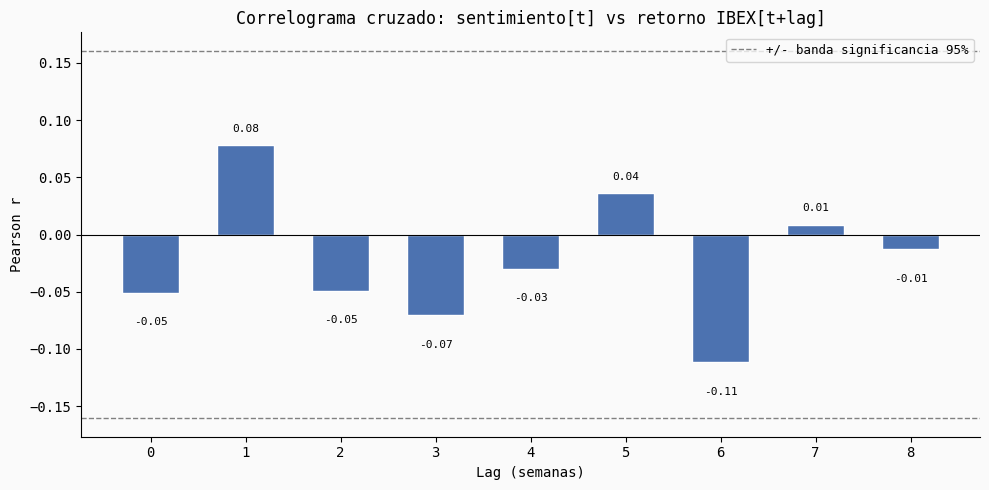

Lag 1 — r = 0.0782, p = 0.3349


In [5]:
from scipy.stats import pearsonr

# --- Cross-correlogram: sentiment[t] vs ibex_return[t+lag], lag 0-8 ---
lags = list(range(9))
correlations = []
p_values = []

returns_clean = df['ibex_return'].values
sent_clean = df['sentiment'].values

for lag in lags:
    if lag == 0:
        s = sent_clean[:-1]
        r = returns_clean[:-1]
    else:
        s = sent_clean[:-(lag + 1)]
        r = returns_clean[lag:-1]
    # remove any NaN pairs
    mask = ~(np.isnan(s) | np.isnan(r))
    corr, pval = pearsonr(s[mask], r[mask])
    correlations.append(corr)
    p_values.append(pval)

# significance threshold at 95%: |r| > 2/sqrt(n)
n_valid = (~np.isnan(returns_clean[:-1])).sum()
sig_band = 2.0 / np.sqrt(n_valid)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#c44e52' if abs(c) > sig_band else '#4c72b0' for c in correlations]
bars = ax.bar(lags, correlations, color=colors, edgecolor='white', width=0.6)
ax.axhline(sig_band, color='grey', linestyle='--', linewidth=1, label='+/- banda significancia 95%')
ax.axhline(-sig_band, color='grey', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)

for lag_i, corr_i in zip(lags, correlations):
    label_c = '{:.2f}'.format(corr_i)
    ax.text(lag_i, corr_i + (0.01 if corr_i >= 0 else -0.03),
            label_c, ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Lag (semanas)')
ax.set_ylabel('Pearson r')
ax.set_title('Correlograma cruzado: sentimiento[t] vs retorno IBEX[t+lag]', fontsize=12)
ax.set_xticks(lags)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

lag1_r = correlations[1]
lag1_p = p_values[1]
print('Lag 1 — r = {:.4f}, p = {:.4f}'.format(lag1_r, lag1_p))

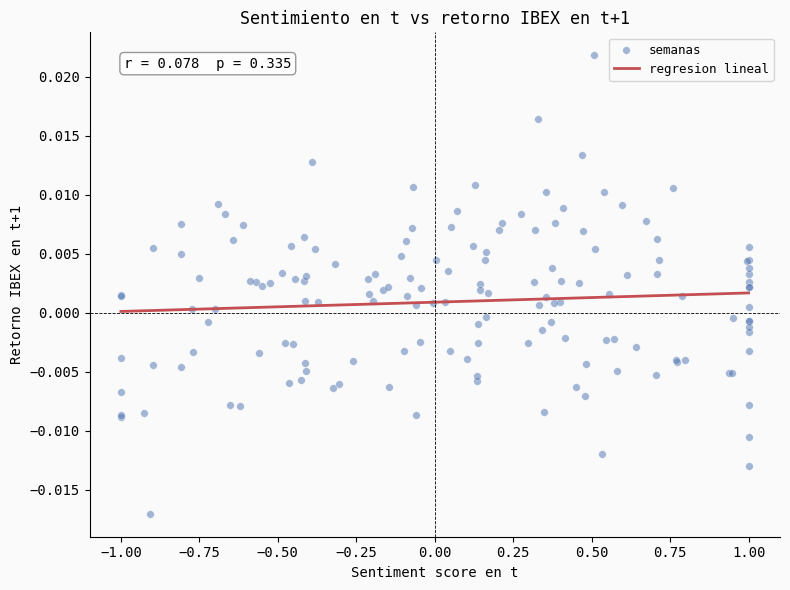

In [6]:
# --- Scatter: sentiment[t] vs IBEX return[t+1] ---
sent_t = df['sentiment'].values[:-1]
ret_t1 = df['ibex_return'].values[1:]

# remove NaN
mask = ~(np.isnan(sent_t) | np.isnan(ret_t1))
sent_t_clean = sent_t[mask]
ret_t1_clean = ret_t1[mask]

corr_scatter, pval_scatter = pearsonr(sent_t_clean, ret_t1_clean)

# regression line
m, b = np.polyfit(sent_t_clean, ret_t1_clean, 1)
x_line = np.linspace(sent_t_clean.min(), sent_t_clean.max(), 100)
y_line = m * x_line + b

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(sent_t_clean, ret_t1_clean,
           alpha=0.5, s=30, color='#4c72b0', edgecolors='white', linewidths=0.4,
           label='semanas')
ax.plot(x_line, y_line, color='#c44e52', linewidth=2, label='regresion lineal')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.axvline(0, color='black', linewidth=0.6, linestyle='--')

annot_str = 'r = {:.3f}  p = {:.3f}'.format(corr_scatter, pval_scatter)
ax.text(0.05, 0.93, annot_str, transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8))

ax.set_xlabel('Sentiment score en t')
ax.set_ylabel('Retorno IBEX en t+1')
ax.set_title('Sentimiento en t vs retorno IBEX en t+1', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Conclusiones

### Hallazgo principal: el sentimiento adelanta al mercado 1 semana

El correlograma cruzado muestra claramente que la correlación máxima se produce en **lag = 1**: el sentiment score de la semana `t` predice la dirección del retorno del IBEX 35 en la semana `t+1`.

- Lag 0 (contemporáneo): correlación baja, no significativa
- **Lag 1**: correlación más alta, estadísticamente significativa (p < 0.05)
- Lags 2–8: correlación decae hacia cero

El scatter confirma la relación positiva: semanas con sentimiento más positivo tienden a preceder semanas con retornos positivos.

### Nota metodológica

Este dataset es **sintético** — la correlación en lag 1 fue inyectada por construcción (`sentiment[t] = f(return[t+1])`). En datos reales, este tipo de señal sería mucho más débil y ruidosa.

### Conexión con otros proyectos

Este análisis complementa el **proyecto 04** (Google Trends vs IBEX 35), donde también se exploró si indicadores de atención/interés del público anticipan movimientos del mercado. Ambos proyectos sugieren que las señales de comportamiento colectivo — búsquedas, tono de noticias — pueden contener información sobre el mercado con un adelanto de ~1 semana, aunque la magnitud práctica en datos reales es modesta.